In [17]:
%reload_ext autoreload
%autoreload 2
import os, sys; sys.path.append(os.getcwd())
import pandas as pd
import matplotlib.pyplot as plt
import import_ipynb
from data import load_spy
from features import make_features
from model import rolling_predict
from backtesting5 import backtest_long_flat, make_trend_gate
from metrics2 import performance

PERFORMANCE: {'n_days': 3468, 'ann_return': 0.08129414461041073, 'ann_vol': 0.1546508913760904, 'sharpe': 0.5256623087461824, 'sortino': 0.589289361114013, 'max_drawdown': -0.3410474689324393, 'win_rate': 0.46655132641291813, 'win_rate_nonzero': 0.5429530201342282, 'win_rate_active': 0.5462525320729237, 'n_trades': 25, 'trade_win_rate': 0.6, 'avg_trade_return': 0.04964584472603167, 'median_trade_return': 0.016118420293180093, 'profit_factor': 4.455953722778086, 'turnover_pa': 0.07266435986159168}


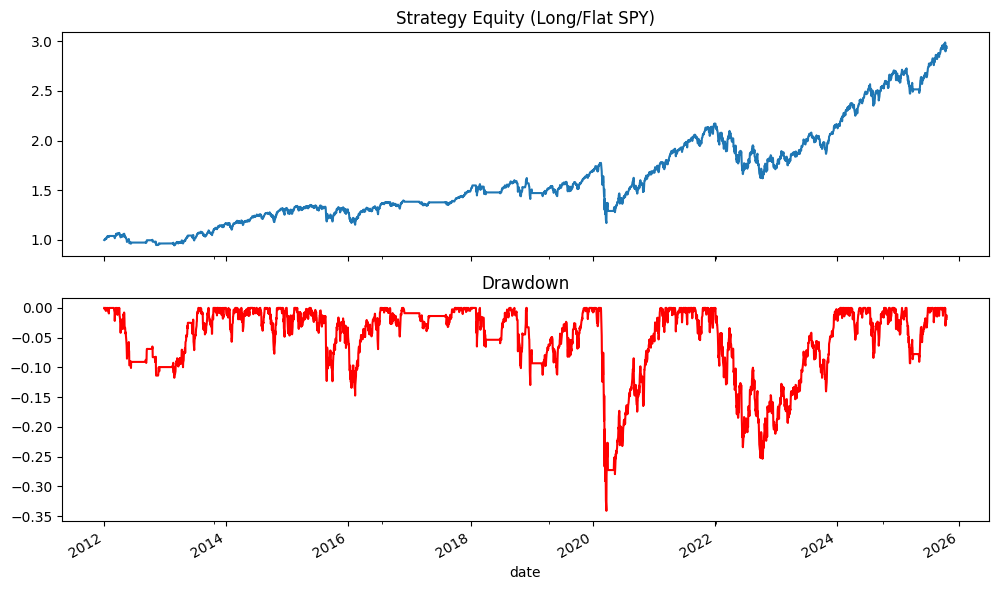

In [23]:
if __name__ == "__main__": 
    df = load_spy(start="2005-01-01")
    feat = make_features(df)

    p_up = rolling_predict(feat, start_year=2012, model_name="logreg")

    ##thr_series = p_up.rolling(63).quantile(0.70).shift(1)
    close = df["close"]
    gate = make_trend_gate(close, lookback=120, slope_window=10, min_slope=-0.0005)
    bt   = backtest_long_flat(close, p_up, threshold=0.535, gate=None)
    
    perf = performance(bt)
    print("PERFORMANCE:", perf)

    equity = (1 + bt['strat_ret']).cumprod()
    peak = equity.cummax()
    drawdown = equity/peak - 1.0

    fig, ax = plt.subplots(2, 1, figsize=(10,6), sharex=True)
    equity.plot(ax=ax[0], title="Strategy Equity (Long/Flat SPY)")
    drawdown.plot(ax=ax[1], color="red", title="Drawdown")
    plt.tight_layout()
    plt.show()